In [ ]:
from sklearn.datasets import load_iris
from sklearn import model_selection as skms
from sklearn import neighbors
from sklearn import preprocessing as skpre # Import sklearn.preprocessing and assign it the alias skpre
import matplotlib.pyplot as plt
import seaborn as sns # Also import seaborn for swarmplot
iris = load_iris()

checkout = [0, 50, 100]
print("Original Encoding")
print(iris.target[checkout])
print("'Multi-label' Encoding")
print(skpre.label_binarize(iris.target, classes=[0, 1, 2])[checkout])

Original Encoding
[0 1 2]
'Multi-label' Encoding
[[1 0 0]
 [0 1 0]
 [0 0 1]]


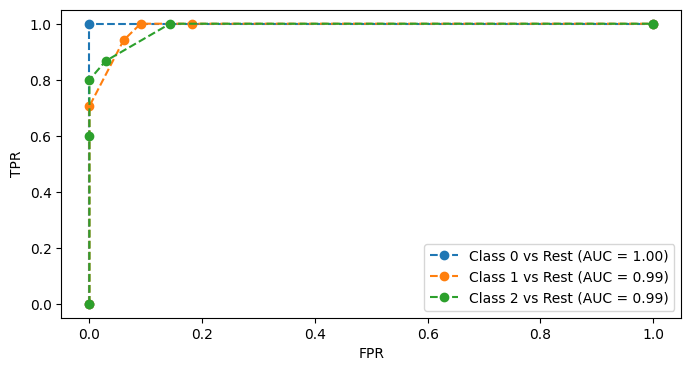

In [ ]:
iris_multi_tgt = skpre.label_binarize(iris.target, classes=[0, 1, 2])
# im --> "iris multi"
(im_train_ftrs, im_test_ftrs,
  im_train_tgt, im_test_tgt) = skms.train_test_split(iris.data,
    iris_multi_tgt, test_size=.33, random_state=21)
# knn wrapped up in one-versus-rest (3 classifiers)
knn = neighbors.KNeighborsClassifier(n_neighbors=5)
from sklearn.multiclass import OneVsRestClassifier # Import OneVsRestClassifier
from sklearn import metrics # Import metrics
ovr_knn = OneVsRestClassifier(knn)
pred_probs = (ovr_knn.fit(im_train_ftrs, im_train_tgt)
  .predict_proba(im_test_ftrs))


# make ROC plots
lbl_fmt = "Class {} vs Rest (AUC = {:.2f})"
fig,ax = plt.subplots(figsize=(8, 4))
for cls in [0, 1, 2]:
  fpr, tpr, _ = metrics.roc_curve(im_test_tgt[:,cls],
    pred_probs[:,cls])
  label = lbl_fmt.format(cls, metrics.auc(fpr,tpr))
  ax.plot(fpr, tpr, 'o--', label=label)
ax.legend()
ax.set_xlabel("FPR")
ax.set_ylabel("TPR");

In [ ]:
# Za svaki od 3 klasifikatora (klasa 0, 1, 2)
for i in range(3):
    print(f"\nKlasa {i}:")

    # Stvarna binarna klasa i predikcija vjerojatnosti za tu klasu
    y_true_bin = im_test_tgt[:, i]
    y_score = pred_probs[:, i]

    # Izračun ROC metrika
    fpr, tpr, thresholds = metrics.roc_curve(y_true_bin, y_score)

    # Ispis svih pragova i odgovarajućih TPR/FPR vrijednosti
    for j, thresh in enumerate(thresholds):
        print(f"Prag: {thresh:.2f} | TPR: {tpr[j]:.2f} | FPR: {fpr[j]:.2f}")




Klasa 0:
Prag: inf | TPR: 0.00 | FPR: 0.00
Prag: 1.00 | TPR: 1.00 | FPR: 0.00
Prag: 0.00 | TPR: 1.00 | FPR: 1.00

Klasa 1:
Prag: inf | TPR: 0.00 | FPR: 0.00
Prag: 1.00 | TPR: 0.71 | FPR: 0.00
Prag: 0.60 | TPR: 0.94 | FPR: 0.06
Prag: 0.40 | TPR: 1.00 | FPR: 0.09
Prag: 0.20 | TPR: 1.00 | FPR: 0.18
Prag: 0.00 | TPR: 1.00 | FPR: 1.00

Klasa 2:
Prag: inf | TPR: 0.00 | FPR: 0.00
Prag: 1.00 | TPR: 0.60 | FPR: 0.00
Prag: 0.80 | TPR: 0.80 | FPR: 0.00
Prag: 0.60 | TPR: 0.87 | FPR: 0.03
Prag: 0.20 | TPR: 1.00 | FPR: 0.14
Prag: 0.00 | TPR: 1.00 | FPR: 1.00
